# 20.11-13 Percentiles, Quartiles, Five-Number Summary, Covariance, and Correlation

This notebook covers standard descriptive statistics and bivariate relationship measures:

1. **Percentiles and Quartiles** (20.11): Dividing datasets into parts to locate values relative to the rest of the distribution.
2. **Five-Number Summary & Outlier Detection** (20.12): Building the five-number summary, visual inspection using Box Plots, and mathematical detection of outliers using the IQR boundary.
3. **Covariance and Correlation** (20.13): Measuring relationships between two numerical variables, understanding scale-independence, and using Pearson vs. Spearman correlation coefficients.

## 1) Percentiles and Quartiles (20.11)

### What is a Percentile?
A **percentile** is a measure used in statistics indicating the value below which a given percentage of observations in a group of observations falls. For example, the 70th percentile is the value below which 70% of the data points may be found.

The formula for finding the rank $i$ of a percentile $P_k$ in an ordered dataset of $n$ elements is:
$$i = \frac{k}{100} \times (n - 1) + 1$$

Where:
- $k$ is the desired percentile (e.g., 90 for the 90th percentile).
- $n$ is the number of items in the dataset.
- $i$ is the index/position of the value in the sorted list.

If $i$ is an integer, the $k$-th percentile is the value at index $i$. If $i$ is not an integer, we interpolate linearly between the values on either side of $i$.

### What are Quartiles?
Quartiles are values that divide a sorted dataset into four equal parts:
1. **First Quartile ($Q_1$)**: The 25th percentile. 25% of the data lies below $Q_1$ and 75% lies above it.
2. **Second Quartile ($Q_2$ / Median)**: The 50th percentile. 50% of the data lies below $Q_2$ and 50% lies above it.
3. **Third Quartile ($Q_3$)**: The 75th percentile. 75% of the data lies below $Q_3$ and 25% lies above it.

In [1]:
import numpy as np
import pandas as pd

# Let's generate a list of employee salaries (in thousands)
salaries = np.array([45, 52, 54, 58, 60, 65, 72, 80, 95, 110, 120])

# Sorting the data (formula requires sorted order)
salaries_sorted = np.sort(salaries)
print("Sorted Salaries (in $K):", salaries_sorted)

# Calculate Q1 (25th percentile), Q2 (Median), and Q3 (75th percentile)
q1 = np.percentile(salaries, 25)
median = np.percentile(salaries, 50) # or np.median(salaries)
q3 = np.percentile(salaries, 75)

# Calculate other specific percentiles (e.g. 90th and 95th)
p90 = np.percentile(salaries, 90)
p95 = np.percentile(salaries, 95)

print("\n--- Percentiles and Quartiles ---")
print(f"Q1 (25th Percentile): ${q1:.2f}K")
print(f"Q2 / Median (50th Percentile): ${median:.2f}K")
print(f"Q3 (75th Percentile): ${q3:.2f}K")
print(f"90th Percentile: ${p90:.2f}K")
print(f"95th Percentile: ${p95:.2f}K")

# Using Pandas Series to show the same calculations
salary_series = pd.Series(salaries)
print("\n--- Pandas Quantile Results ---")
print(salary_series.quantile([0.25, 0.50, 0.75, 0.90, 0.95]).to_string())

Sorted Salaries (in $K): [ 45  52  54  58  60  65  72  80  95 110 120]

--- Percentiles and Quartiles ---
Q1 (25th Percentile): $56.00K
Q2 / Median (50th Percentile): $65.00K
Q3 (75th Percentile): $87.50K
90th Percentile: $110.00K
95th Percentile: $115.00K

--- Pandas Quantile Results ---
0.25     56.0
0.50     65.0
0.75     87.5
0.90    110.0
0.95    115.0


## 2) The Five-Number Summary, IQR, Box Plots, and Outliers (20.12)

### The Five-Number Summary
A **five-number summary** consists of five values that provide a quick visual and statistical overview of the distribution of a dataset. These five values are:
1. **Minimum value** ($\text{Min}$)
2. **First Quartile** ($Q_1$)
3. **Median** ($Q_2$)
4. **Third Quartile** ($Q_3$)
5. **Maximum value** ($\text{Max}$)

### Interquartile Range (IQR)
The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data. It is less sensitive to extreme values (outliers) than the range.
$$\text{IQR} = Q_3 - Q_1$$

### Outliers
An **outlier** is a data point that is significantly different from the rest of the dataset. A standard heuristic for identifying outliers is the **IQR rule**:
- **Lower Bound** = $Q_1 - 1.5 \times \text{IQR}$
- **Upper Bound** = $Q_3 + 1.5 \times \text{IQR}$

Any data point falling below the Lower Bound or above the Upper Bound is classified as an outlier.

### Box Plots (Box and Whisker Plots)
A Box Plot visually displays the five-number summary:
- The **box** extends from $Q_1$ to $Q_3$, representing the IQR.
- A **line/bar** inside the box indicates the Median ($Q_2$).
- The **whiskers** extend to the smallest and largest non-outlying values (within the Lower and Upper bounds).
- **Outliers** are plotted individually as points (markers) beyond the whiskers.

Dataset: [12 14 15 16 17 18 19 20 21 22 23 24 25 38 42  3]

--- Five-Number Summary ---
Minimum: 3
Quartile 1 (Q1): 15.75
Median (Q2): 19.5
Quartile 3 (Q3): 23.25
Maximum: 42

--- Outlier Detection ---
IQR (Q3 - Q1): 7.5
Lower Bound (Q1 - 1.5*IQR): 4.5
Upper Bound (Q3 + 1.5*IQR): 34.5
Outliers detected: [38, 42, 3]


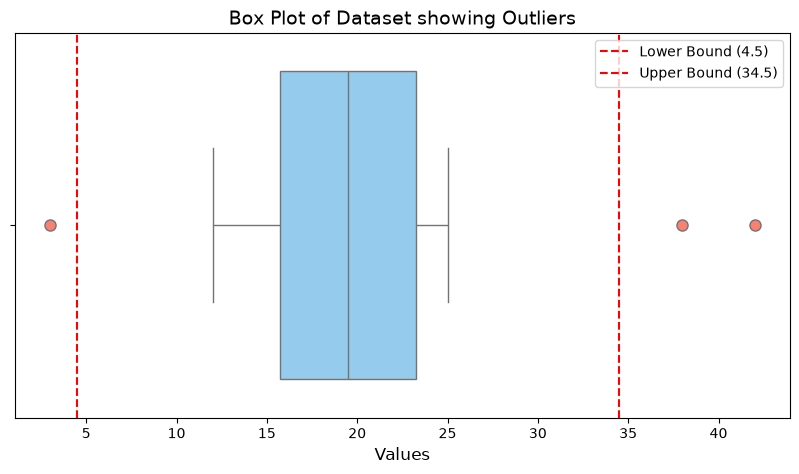

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataset with some extreme values (outliers)
data = np.array([12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 38, 42, 3]) # 38, 42, and 3 are potential outliers

# Calculate statistics for Five-Number Summary
min_val = np.min(data)
q1 = np.percentile(data, 25)
median = np.median(data)
q3 = np.percentile(data, 75)
max_val = np.max(data)

# Calculate IQR and outlier bounds
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]
clean_data = data[(data >= lower_bound) & (data <= upper_bound)]

print("Dataset:", data)
print("\n--- Five-Number Summary ---")
print(f"Minimum: {min_val}")
print(f"Quartile 1 (Q1): {q1}")
print(f"Median (Q2): {median}")
print(f"Quartile 3 (Q3): {q3}")
print(f"Maximum: {max_val}")

print("\n--- Outlier Detection ---")
print(f"IQR (Q3 - Q1): {iqr}")
print(f"Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound}")
print(f"Outliers detected: {outliers.tolist()}")

# Visualizing using Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=data, color='lightskyblue', flierprops={'markerfacecolor': 'salmon', 'marker': 'o', 'markersize': 8})
plt.title("Box Plot of Dataset showing Outliers", fontsize=14)
plt.xlabel("Values", fontsize=12)
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound ({lower_bound})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound ({upper_bound})')
plt.legend()
plt.show()

## 3) Covariance and Correlation (20.13)

When observing two variables, we want to know whether and how they are related. 

### A. Covariance
**Covariance** measures the direction of the linear relationship between two variables. It tells us whether the variables tend to move in the same direction (positive covariance) or in opposite directions (negative covariance).

- **Population Covariance**:
  $$\sigma_{xy} = \frac{\sum (X_i - \mu_x)(Y_i - \mu_y)}{N}$$
- **Sample Covariance**:
  $$s_{xy} = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{n - 1}$$

**Limitation**: Covariance depends on the scale of measurement. For example, if we measure heights in meters instead of centimeters, the covariance magnitude changes. Thus, we cannot tell the *strength* of the relationship from the covariance value alone.

### B. Correlation (Pearson's Correlation Coefficient)
**Correlation** standardizes covariance by dividing it by the standard deviations of both variables. This limits the correlation coefficient ($r$ or $\rho$) to a scale between $-1$ and $+1$.
$$r = \frac{s_{xy}}{s_x s_y}$$

Where:
- $r = 1$: Perfect positive linear relationship.
- $r = -1$: Perfect negative linear relationship.
- $r = 0$: No linear relationship (variables are linearly independent).

### C. Pearson vs. Spearman Correlation
1. **Pearson Correlation**:
   - Measures the **linear** relationship between two continuous variables.
   - Assumes normally distributed datasets and homoscedasticity.
2. **Spearman Rank Correlation**:
   - Measures a **monotonic** relationship (whether they increase/decrease together, even if not linearly).
   - Works by ranking the data points and then computing the Pearson correlation of the ranks.
   - Robust to outliers and applicable to ordinal/ranked data.

--- Covariance Matrix ---
                 X  Pos_Linear  Neg_Linear  Monotonic  No_Relation
X             6.96       17.55      -12.50      34.20        -0.06
Pos_Linear   17.55       46.13      -31.76      86.60        -0.77
Neg_Linear  -12.50      -31.76       23.78     -62.32         0.06
Monotonic    34.20       86.60      -62.32     205.91         1.11
No_Relation  -0.06       -0.77        0.06       1.11         7.03

--- Pearson Correlation Matrix (Linear) ---
                X  Pos_Linear  Neg_Linear  Monotonic  No_Relation
X            1.00        0.98       -0.97       0.90        -0.01
Pos_Linear   0.98        1.00       -0.96       0.89        -0.04
Neg_Linear  -0.97       -0.96        1.00      -0.89         0.00
Monotonic    0.90        0.89       -0.89       1.00         0.03
No_Relation -0.01       -0.04        0.00       0.03         1.00

--- Spearman Correlation Matrix (Monotonic) ---
                X  Pos_Linear  Neg_Linear  Monotonic  No_Relation
X            1.0

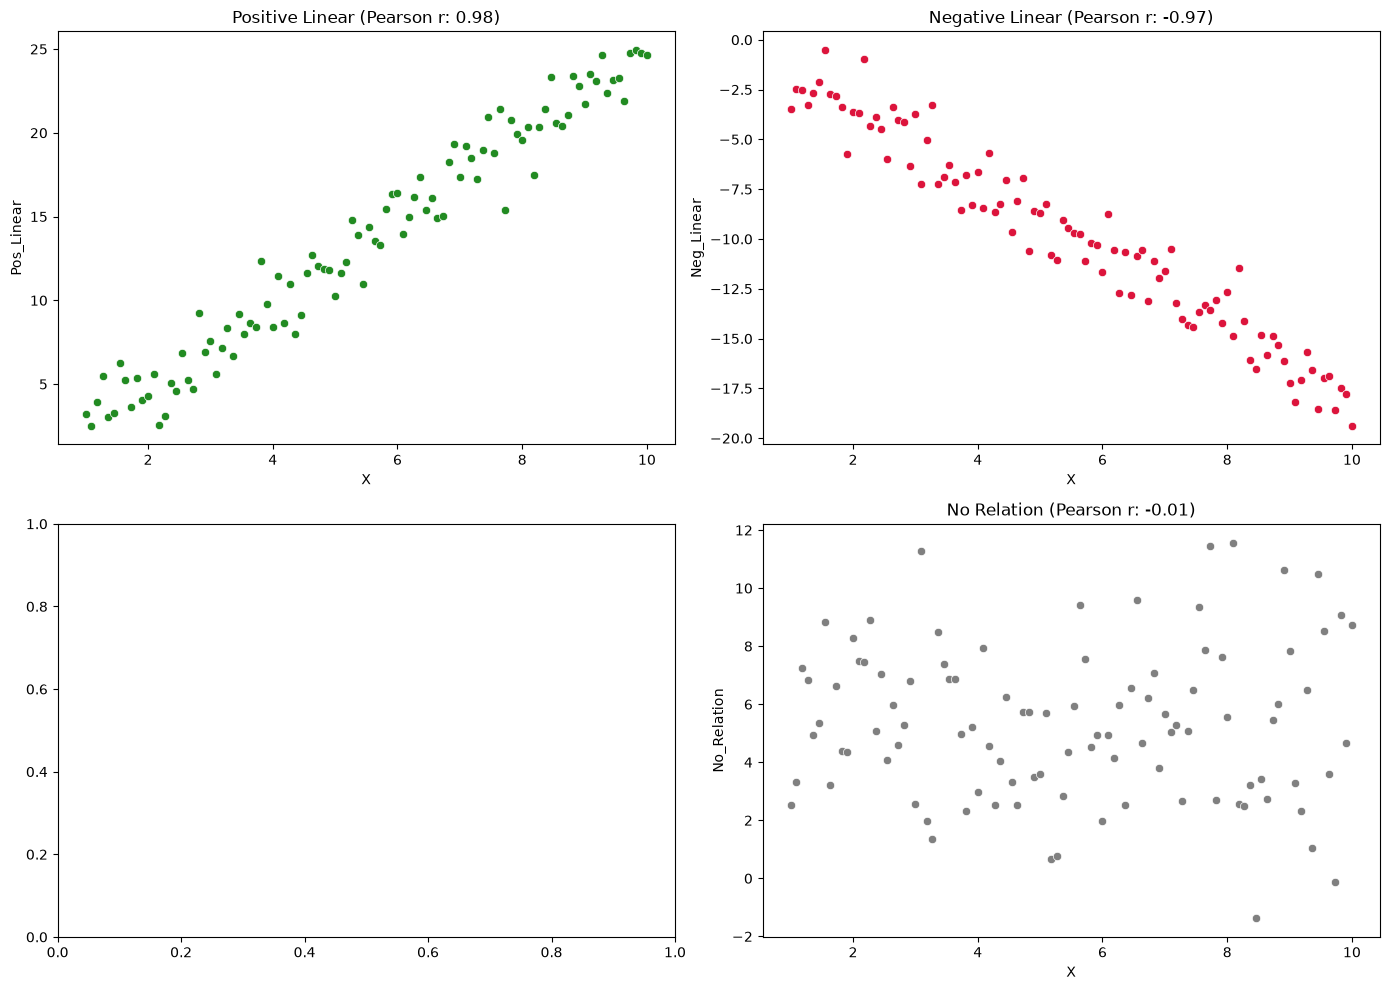

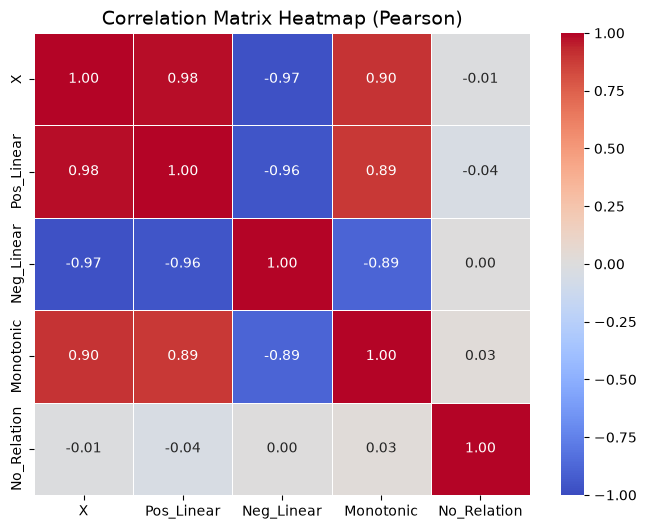

In [4]:
# Generate synthetic variables showing different relationship types
np.random.seed(42)
X = np.linspace(1, 10, 100)

# 1. Strong Positive Linear Relationship
Y_pos = 2.5 * X + np.random.normal(0, 1.5, 100)

# 2. Strong Negative Linear Relationship
Y_neg = -1.8 * X + np.random.normal(0, 1.2, 100)

# 3. Monotonic but Non-Linear Relationship (Exponential)
Y_mono = np.exp(X / 2.5) + np.random.normal(0, 1.0, 100)

# 4. No Relationship
Y_none = np.random.normal(5, 3, 100)

# Store in a DataFrame for ease of analysis
df = pd.DataFrame({
    'X': X,
    'Pos_Linear': Y_pos,
    'Neg_Linear': Y_neg,
    'Monotonic': Y_mono,
    'No_Relation': Y_none
})

# Calculate Covariance Matrix
print("--- Covariance Matrix ---")
print(df.cov().round(2))

# Calculate Pearson Correlation Matrix
print("\n--- Pearson Correlation Matrix (Linear) ---")
print(df.corr(method='pearson').round(2))

# Calculate Spearman Correlation Matrix (Monotonic)
print("\n--- Spearman Correlation Matrix (Monotonic) ---")
print(df.corr(method='spearman').round(2))

# Set up the visualization grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Positive Linear
sns.scatterplot(x=df['X'], y=df['Pos_Linear'], ax=axes[0, 0], color='forestgreen')
axes[0, 0].set_title(f"Positive Linear (Pearson r: {df['X'].corr(df['Pos_Linear']):.2f})")

# Plot 2: Negative Linear
sns.scatterplot(x=df['X'], y=df['Neg_Linear'], ax=axes[0, 1], color='crimson')
axes[0, 1].set_title(f"Negative Linear (Pearson r: {df['X'].corr(df['Neg_Linear']):.2f})")



# Plot 3: No Relation
sns.scatterplot(x=df['X'], y=df['No_Relation'], ax=axes[1, 1], color='gray')
axes[1, 1].set_title(f"No Relation (Pearson r: {df['X'].corr(df['No_Relation']):.2f})")

plt.tight_layout()
plt.show()

# Let's plot a Correlation Heatmap of the variables
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Pearson)", fontsize=14)
plt.show()

## Key Takeaways

- **Percentiles and Quartiles** locate where individual data values sit relative to the rest of the distribution.
- The **Five-Number Summary** (Min, Q1, Median, Q3, Max) provides a rapid visual map of a dataset's distribution.
- **IQR** (Interquartile Range) measures the middle 50% spread, and the **IQR Rule** ($1.5 \times \text{IQR}$) is a robust standard for outlier flagging.
- **Covariance** indicates the direction of linear correlation but is scale-dependent, while **Correlation** standardizes covariance to a $[-1, 1]$ interval.
- **Pearson** correlation tracks linear patterns, while **Spearman** ranks order to measure any monotonic patterns (even non-linear).